In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, DelimitedFiles;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
# Pyplot rcparams
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["text.usetex"] = false;
mlines = pyimport("matplotlib").lines
# General method to give red-green-blue values for plotting
rgb(x, y, z) = [x, y, z] ./ 255

rgb (generic function with 1 method)

In [4]:
# Phonon calculations indicate that only the buckled B substitution lattices are stable
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn33bc_buckled_dir="./BN33BC_Buckled"
bn44bc_dir="./BN44BC"
bn44bc_buckled_dir="./BN44BC_Buckled"
bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"
Ag_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/3Dnew"
Argentene_dir = "/home/gridsan/aligho/Plasmons/Plasmons_Paper/Substitutional_Defects/Argentene/2Dnew"
graphene_dir = "./Graphene";

In [5]:
μ22bc = -2.640839712362954
μ33bc = -2.5
μ44bc = -2.511

μ22nc = -4.713157401278416
μ33nc = -4.716750713951669
μ44nc = -4.624122722539408

-4.624122722539408

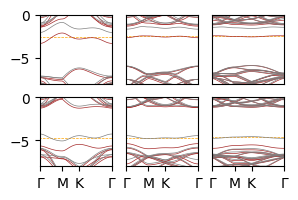

PyObject <matplotlib.collections.LineCollection object at 0x7fabfb6f9f70>

In [7]:
cm = 1/2.54
figure(figsize=(8*cm, 5*cm))

color_up ="brown"
color_dn = "grey"
num_cols = 3
num_rows = 2

subplot(num_rows, num_cols, 1)
plot_bands(bn22bc_dir*"/BN22BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,)
ylim(-8, -0)
xlabel("")
ylabel("")
hlines([μ22bc], -100, 100, color="orange", linestyle="dashed", linewidth=0.5)
xticks([])

subplot(num_rows, num_cols, 4)
plot_bands(bn22nc_dir*"/BN22NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(-8, -0)
xlabel("")
ylabel("")
hlines([μ22nc], -100, 100, color="orange", linestyle="dashed", linewidth=0.5)


subplot(num_rows, num_cols, 2)

plot_bands(bn33bc_dir*"/BN33BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(-8, -0)
xlabel("")
ylabel("")
yticks([])
xticks([])
hlines([μ33bc], -100, 100, color="orange", linestyle="dashed", linewidth=0.5)


subplot(num_rows, num_cols, 5)
plot_bands(bn33nc_dir*"/BN33NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(-8, -0)
xlabel("")
ylabel("")
yticks([])
hlines([μ33nc], -100, 100, color="orange", linestyle="dashed", linewidth=0.5)

subplot(num_rows, num_cols, 3)
plot_bands(bn44bc_dir*"/BN44BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(-8, -0)
xlabel("")
ylabel("")
xticks([])
yticks([])
hlines([μ44bc], -100, 100, color="orange", linestyle="dashed", linewidth=0.5)


subplot(num_rows, num_cols, 6)
plot_bands(bn44nc_dir*"/BN44NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5)
ylim(-8, -0)
xlabel("")
ylabel("")
#title("BN44NC")
yticks([])
hlines([μ44nc], -100, 100, color="orange", linestyle="dashed", linewidth=0.5)


#savefig("AllBands.pdf")

In [35]:
# Now we report the bandwidths

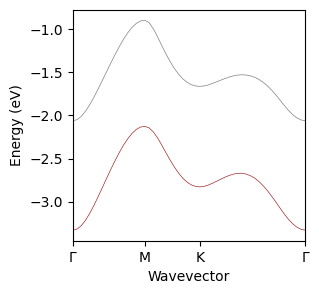

BN22BC bandwidth: 1.2063967746553539
Spin gap: 1.2713682382419984 


In [14]:
figure(figsize=(3, 3))
plot_bands(bn22bc_dir*"/BN22BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,
whichbands=[17])
es_up, es_dn = JJDFTX.bandstruct_properties(bn22bc_dir*"/BN22BC.bands.eigenvals", kpointsfile=bn22bc_dir*"/bandstruct.kpoints",  spin =2);
println("BN22BC bandwidth: $(es_up[17][2] - es_up[17][1])")
println("Spin gap: $(es_dn[17][1] - es_up[17][1]) ")

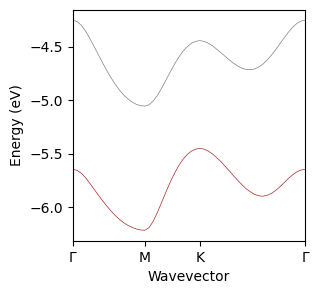

BN22NC bandwidth: 0.8017327954669966
Spin gap: 1.1582201130683885 


In [16]:
figure(figsize=(3, 3))
plot_bands(bn22nc_dir*"/BN22NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5, 
whichbands=[16])
es_up, es_dn = JJDFTX.bandstruct_properties(bn22nc_dir*"/BN22NC.bands.eigenvals", kpointsfile=bn22nc_dir*"/bandstruct.kpoints",  spin =2);

println("BN22NC bandwidth: $(es_dn[16][2] - es_dn[16][1])")
println("Spin gap: $(es_dn[16][1] - es_up[16][1]) ")

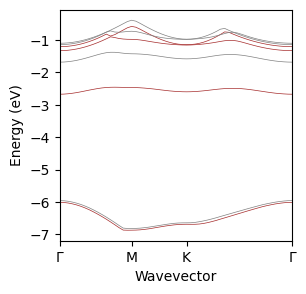

BN33BC bandwidth: 0.21723651486894502
Spin gap: 0.9916860801945471 


In [17]:
figure(figsize=(3, 3))
plot_bands(bn33bc_dir*"/BN33BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,
whichbands=[36, 37, 38, 39])
es_up, es_dn = JJDFTX.bandstruct_properties(bn33bc_dir*"/BN33BC.bands.eigenvals", kpointsfile=bn33bc_dir*"/bandstruct.kpoints",  spin =2);
println("BN33BC bandwidth: $(es_up[37][2] - es_up[37][1])")
println("Spin gap: $(es_dn[37][1] - es_up[37][1]) ")

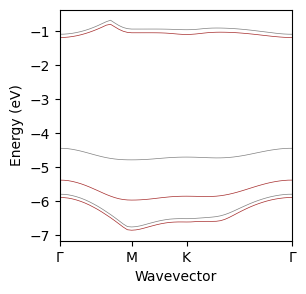

BN33NC bandwidth: 0.3405207981489884
Spin gap: 1.1810458479669688 


In [18]:
figure(figsize=(3, 3))
plot_bands(bn33nc_dir*"/BN33NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5, 
whichbands=[35, 36, 37])
es_up, es_dn = JJDFTX.bandstruct_properties(bn33nc_dir*"/BN33NC.bands.eigenvals", kpointsfile=bn33nc_dir*"/bandstruct.kpoints",  spin =2);

println("BN33NC bandwidth: $(es_dn[36][2]- es_dn[36][1])")
println("Spin gap: $(es_dn[36][1] - es_up[36][1]) ")

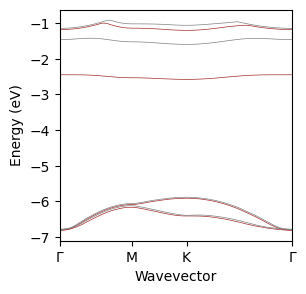

BN44BC bandwidth: 0.1295060107361392
Spin gap: 0.9822971038228117 


In [25]:
figure(figsize=(3, 3))
plot_bands(bn44bc_dir*"/BN44BC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5,
whichbands=[63, 64, 65, 66])
es_up, es_dn = JJDFTX.bandstruct_properties(bn44bc_dir*"/BN44BC.bands.eigenvals", kpointsfile=bn44bc_dir*"/bandstruct.kpoints",  spin =2);
println("BN44BC bandwidth: $(es_up[65][2] - es_up[65][1])")
println("Spin gap: $(es_dn[65][1] - es_up[65][1]) ")

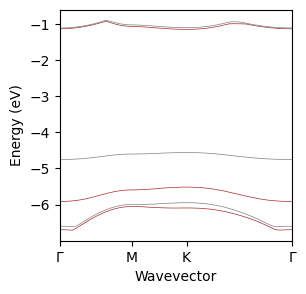

BN44NC bandwidth: 0.19342033695624483
Spin gap: 1.1600830017696655 


In [20]:
figure(figsize=(3, 3))
plot_bands(bn44nc_dir*"/BN44NC.bands.eigenvals", spin = 2, color_up = color_up, color_dn=color_dn, linewidth=0.5, 
whichbands=[63, 64, 65])
es_up, es_dn = JJDFTX.bandstruct_properties(bn44nc_dir*"/BN44NC.bands.eigenvals", kpointsfile=bn44nc_dir*"/bandstruct.kpoints",  spin =2);

println("BN44NC bandwidth: $(es_dn[64][2]- es_dn[64][1])")
println("Spin gap: $(es_dn[64][1] - es_up[64][1]) ")